# ML Stock Selection — Results Report
**S&P 500 Market-Neutral Strategy | LightGBM vs FT-Transformer**

Run scripts 1 → 2 → 2b → 3 → 4 first, then execute all cells here (`Cell → Run All`).

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

DATA_DIR = Path('data')
FIG_DIR  = DATA_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

def perf_stats(r):
    r = r.dropna()
    if len(r) < 6: return {}
    ann    = (1 + r).prod() ** (12 / len(r)) - 1
    vol    = r.std(ddof=1) * np.sqrt(12)
    sharpe = ann / vol if vol > 0 else np.nan
    nav    = (1 + r).cumprod()
    maxdd  = (nav / nav.cummax() - 1).min()
    return dict(months=len(r), ann_pct=ann*100, vol_pct=vol*100,
                sharpe=sharpe, maxdd_pct=maxdd*100)

print('Setup complete.')

Setup complete.


## 1. Data Overview

In [12]:
panel  = pd.read_parquet(DATA_DIR / 'panel_monthly_enriched.parquet')
panel['date'] = pd.to_datetime(panel['date'])

exclude   = {'date', 'ticker', 'fwd_ret_1m'}
feat_cols = [c for c in panel.columns if c not in exclude]

print('─' * 50)
print(f"Stocks:      {panel['ticker'].nunique():,}")
print(f"Date range:  {panel['date'].min().date()} → {panel['date'].max().date()}")
print(f"Months:      {panel['date'].nunique()}")
print(f"Total rows:  {len(panel):,}")
print(f"Features:    {len(feat_cols)}")
print('─' * 50)
print('Features:', feat_cols)

──────────────────────────────────────────────────
Stocks:      502
Date range:  2006-01-25 → 2025-11-28
Months:      239
Total rows:  106,944
Features:    26
──────────────────────────────────────────────────
Features: ['ret_1m', 'ret_3m', 'ret_6m', 'ret_12m', 'rev_1m', 'vol_20d', 'vol_60d', 'vol_252d', 'hl_range', 'vol_ratio_sm', 'vol_ratio_ml', 'price_to_ma20', 'price_to_ma60', 'price_to_ma200', 'ma_20_60_cross', 'ma_60_200_cross', 'nearness_52w', 'amihud_21d', 'up_down_vol', 'skew_60d', 'maxdd_60d', 'mom_2_12', 'mom_accel', 'ir_12m', 'ir_3m', 'rev_signal']


## 2. Strategy Performance Summary

In [13]:
def load_bt(path):
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df.iloc[:, 0])
    ret_col = df.columns[1]
    return df.set_index('date')[ret_col]

# Load backtests
strategies = {}
files = {
    'LGBM Long-Only':    DATA_DIR / 'bt_lgbm.csv',
    'LGBM Long-Short':   DATA_DIR / 'bt_lgbm_ls.csv',
}
# Add transformer results if available
for name, path in [
    ('Transformer Long-Only',  DATA_DIR / 'bt_transformer.csv'),
    ('Transformer Long-Short', DATA_DIR / 'bt_transformer_ls.csv'),
]:
    if path.exists():
        files[name] = path

for name, path in files.items():
    try:
        strategies[name] = load_bt(path)
    except Exception as e:
        print(f'  Could not load {name}: {e}')

# Build summary table
rows = []
for name, ret in strategies.items():
    s = perf_stats(ret)
    rows.append({'Strategy': name, **s})

df_summary = pd.DataFrame(rows).set_index('Strategy')
df_summary.columns = ['Months', 'Ann Return %', 'Volatility %', 'Sharpe', 'Max Drawdown %']
df_summary = df_summary.round(2)
display(df_summary)

,Months,Ann Return %,Volatility %,Sharpe,Max Drawdown %
Strategy,,,,,
LGBM Long-Only,35,33.73,21.84,1.54,-17.80
LGBM Long-Short,35,11.65,14.07,0.83,-8.69
Transformer Long-Only,35,32.28,24.54,1.32,-20.17
Transformer Long-Short,35,20.68,21.26,0.97,-18.15


## 3. NAV Chart — Cumulative Performance

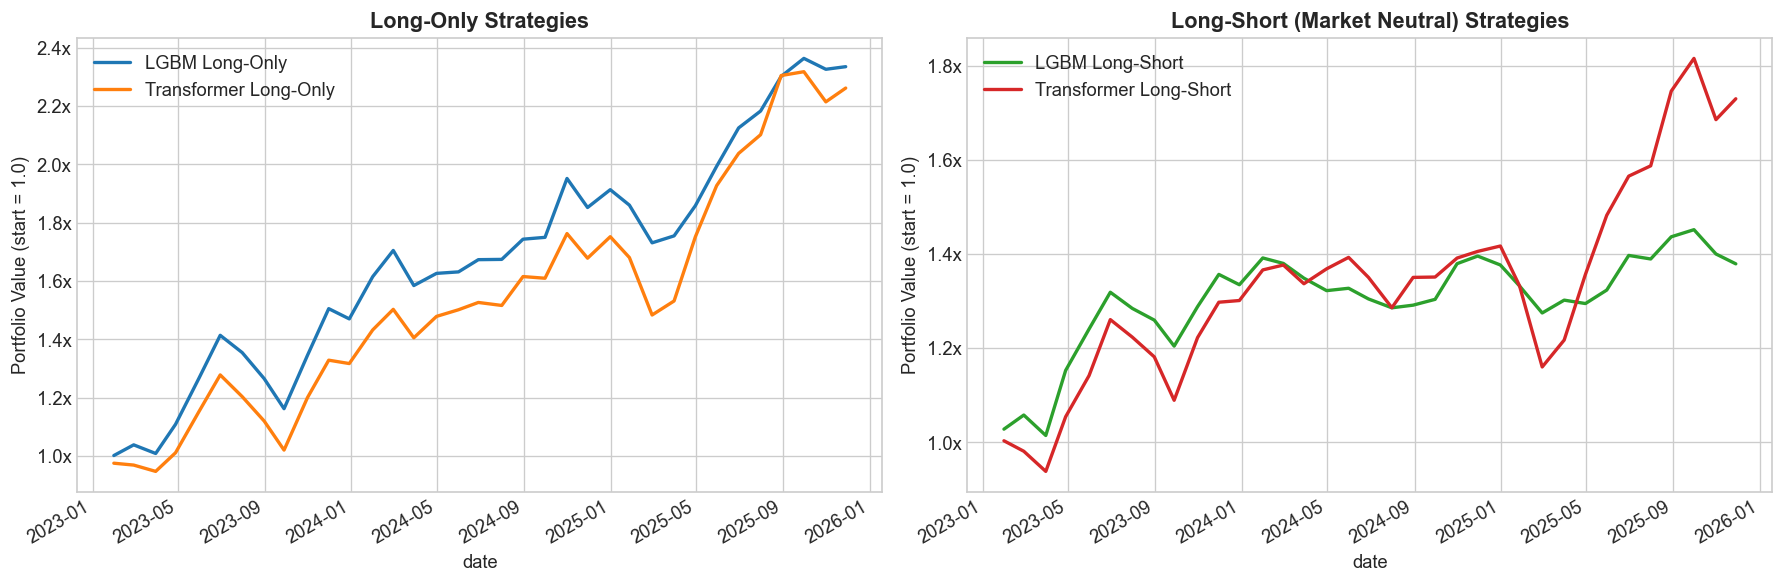

Saved: data/figures/nav_chart.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

COLORS = {
    'LGBM Long-Only':           '#1f77b4',
    'LGBM Long-Short':          '#2ca02c',
    'Transformer Long-Only':    '#ff7f0e',
    'Transformer Long-Short':   '#d62728',
    'S&P 500':                  '#7f7f7f',
}

# Try to load SPX benchmark
try:
    spx = pd.read_csv(DATA_DIR / 'spx_monthly.csv')
    spx['date'] = pd.to_datetime(spx['date'])
    spx = spx.set_index('date')['spx_ret']
    strategies['S&P 500'] = spx
except:
    pass

# --- Left: Long-Only strategies
ax = axes[0]
for name in ['LGBM Long-Only', 'Transformer Long-Only', 'S&P 500']:
    if name not in strategies: continue
    ret = strategies[name]
    nav = (1 + ret).cumprod()
    nav.plot(ax=ax, label=name, color=COLORS.get(name, None), linewidth=2)

ax.set_title('Long-Only Strategies', fontweight='bold', fontsize=13)
ax.set_ylabel('Portfolio Value (start = 1.0)')
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.1f}x'))

# --- Right: Long-Short strategies
ax = axes[1]
for name in ['LGBM Long-Short', 'Transformer Long-Short']:
    if name not in strategies: continue
    ret = strategies[name]
    nav = (1 + ret).cumprod()
    nav.plot(ax=ax, label=name, color=COLORS.get(name, None), linewidth=2)

ax.set_title('Long-Short (Market Neutral) Strategies', fontweight='bold', fontsize=13)
ax.set_ylabel('Portfolio Value (start = 1.0)')
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.1f}x'))

plt.tight_layout()
plt.savefig(FIG_DIR / 'nav_chart.png', bbox_inches='tight')
plt.show()
print('Saved: data/figures/nav_chart.png')

## 4. Rolling 12-Month Sharpe (Consistency Check)

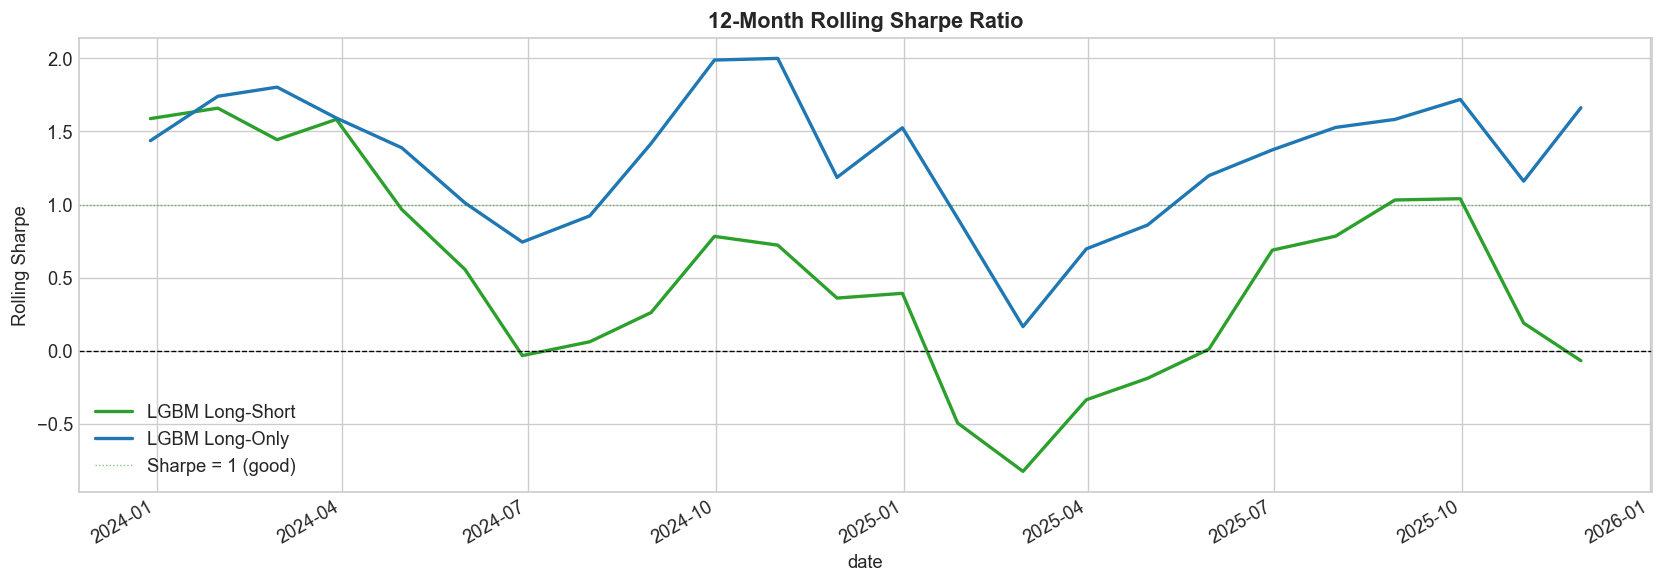

Saved: data/figures/rolling_sharpe.png


In [15]:
fig, ax = plt.subplots(figsize=(14, 5))

for name, col in [('LGBM Long-Short', '#2ca02c'), ('LGBM Long-Only', '#1f77b4')]:
    if name not in strategies: continue
    ret = strategies[name]
    roll_sharpe = ret.rolling(12).apply(
        lambda r: r.mean() / r.std() * np.sqrt(12) if r.std() > 0 else np.nan
    )
    roll_sharpe.plot(ax=ax, label=name, color=col, linewidth=2)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(1, color='green', linewidth=0.8, linestyle=':', alpha=0.5, label='Sharpe = 1 (good)')
ax.set_title('12-Month Rolling Sharpe Ratio', fontweight='bold', fontsize=13)
ax.set_ylabel('Rolling Sharpe')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'rolling_sharpe.png', bbox_inches='tight')
plt.show()
print('Saved: data/figures/rolling_sharpe.png')

## 5. Feature Importance (LightGBM)

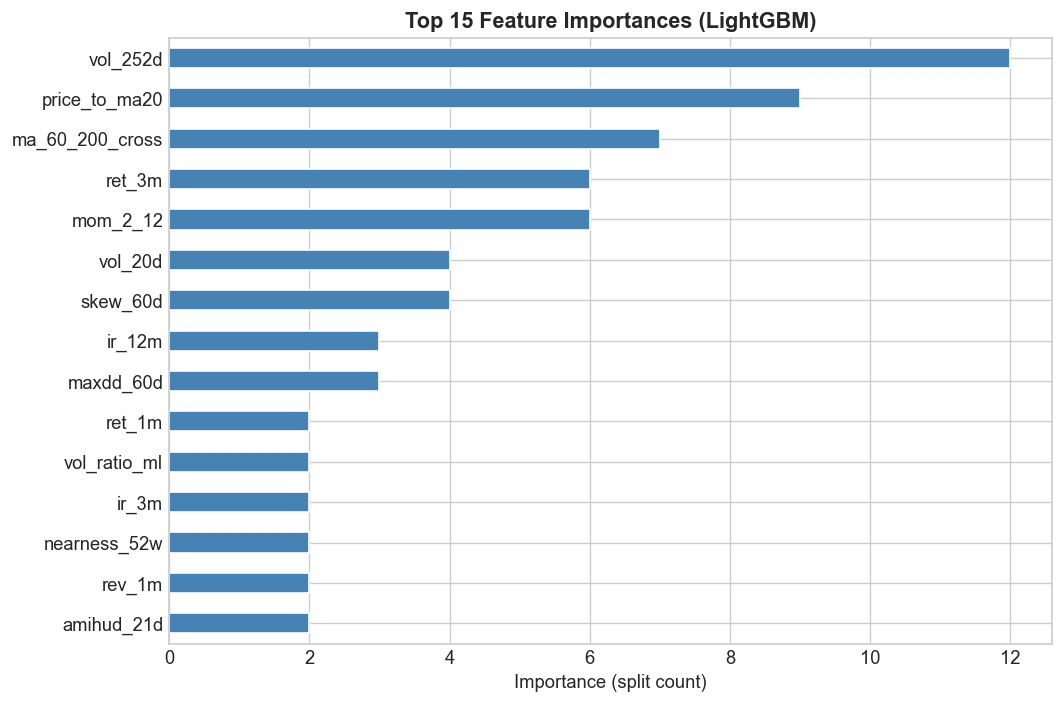

Saved: data/figures/feature_importance.png

Top 15 features:
vol_252d           12
price_to_ma20       9
ma_60_200_cross     7
ret_3m              6
mom_2_12            6
vol_20d             4
skew_60d            4
ir_12m              3
maxdd_60d           3
ret_1m              2
vol_ratio_ml        2
ir_3m               2
nearness_52w        2
rev_1m              2
amihud_21d          2


In [16]:
# Refit a quick LightGBM on train set to extract feature importances
# (uses stored scores indirectly; re-training is the cleanest approach)
from lightgbm import LGBMRegressor
import sys
sys.path.insert(0, '.')  # import config from project dir
from config import LGBM_PARAMS, TRAIN_END, VALID_END, START_DATE

panel2 = panel[panel['date'] >= START_DATE].copy()
train_end = pd.Timestamp(TRAIN_END)
valid_end = pd.Timestamp(VALID_END)

tr = panel2[panel2['date'] <= train_end].dropna(subset=feat_cols + ['fwd_ret_1m'])
va = panel2[(panel2['date'] > train_end) & (panel2['date'] <= valid_end)].dropna(subset=feat_cols + ['fwd_ret_1m'])

import lightgbm as lgb
m = LGBMRegressor(**LGBM_PARAMS)
m.fit(
    tr[feat_cols], tr['fwd_ret_1m'],
    eval_set=[(va[feat_cols], va['fwd_ret_1m'])],
    eval_metric='l2',
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)],
)

fi = pd.Series(m.feature_importances_, index=feat_cols).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
bars = fi.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Feature Importances (LightGBM)', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance (split count)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'feature_importance.png', bbox_inches='tight')
plt.show()
print('Saved: data/figures/feature_importance.png')
print('\nTop 15 features:')
print(fi[::-1].to_string())

## 6. Monthly Return Distribution

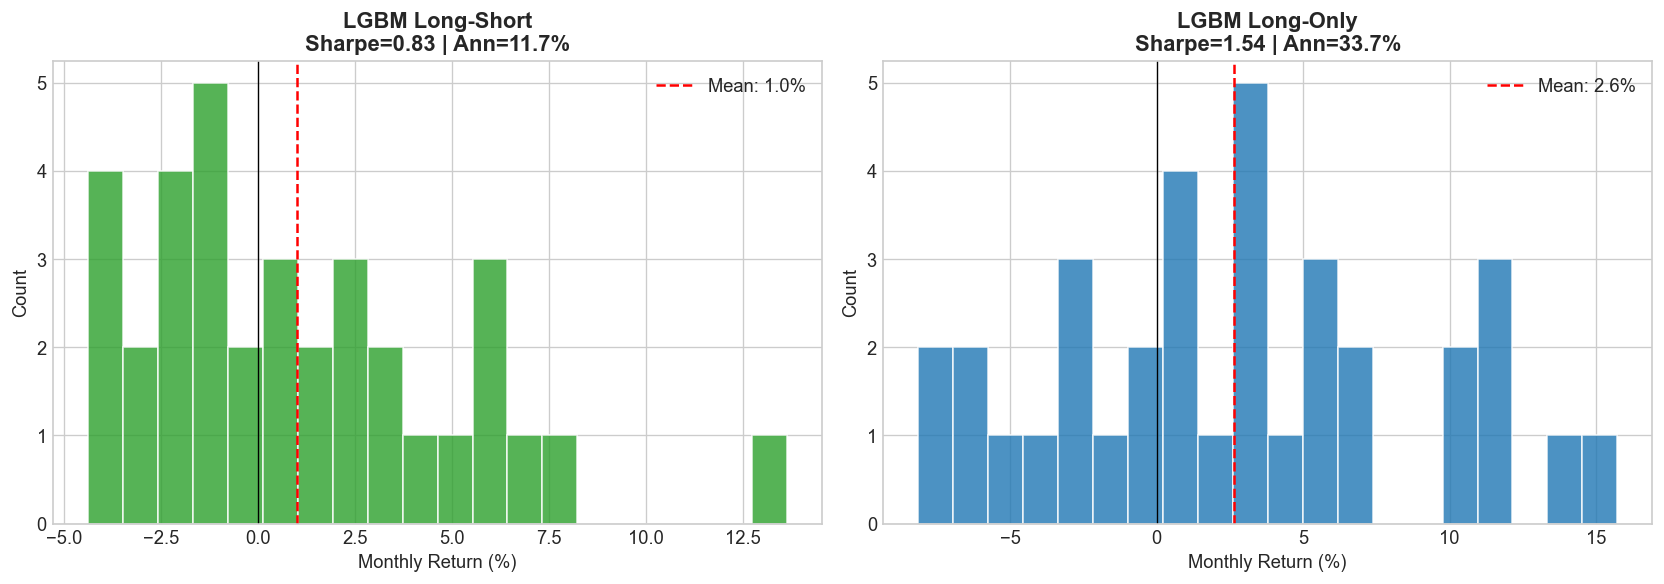

Saved: data/figures/return_distribution.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, col) in zip(axes, [
    ('LGBM Long-Short', '#2ca02c'),
    ('LGBM Long-Only',  '#1f77b4'),
]):
    if name not in strategies: continue
    ret = strategies[name].dropna() * 100
    s   = perf_stats(strategies[name])
    ax.hist(ret, bins=20, color=col, edgecolor='white', alpha=0.8)
    ax.axvline(ret.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {ret.mean():.1f}%')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{name}\nSharpe={s["sharpe"]:.2f} | Ann={s["ann_pct"]:.1f}%',
                 fontweight='bold')
    ax.set_xlabel('Monthly Return (%)')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'return_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: data/figures/return_distribution.png')

## 7. Score Distribution (Model Confidence)

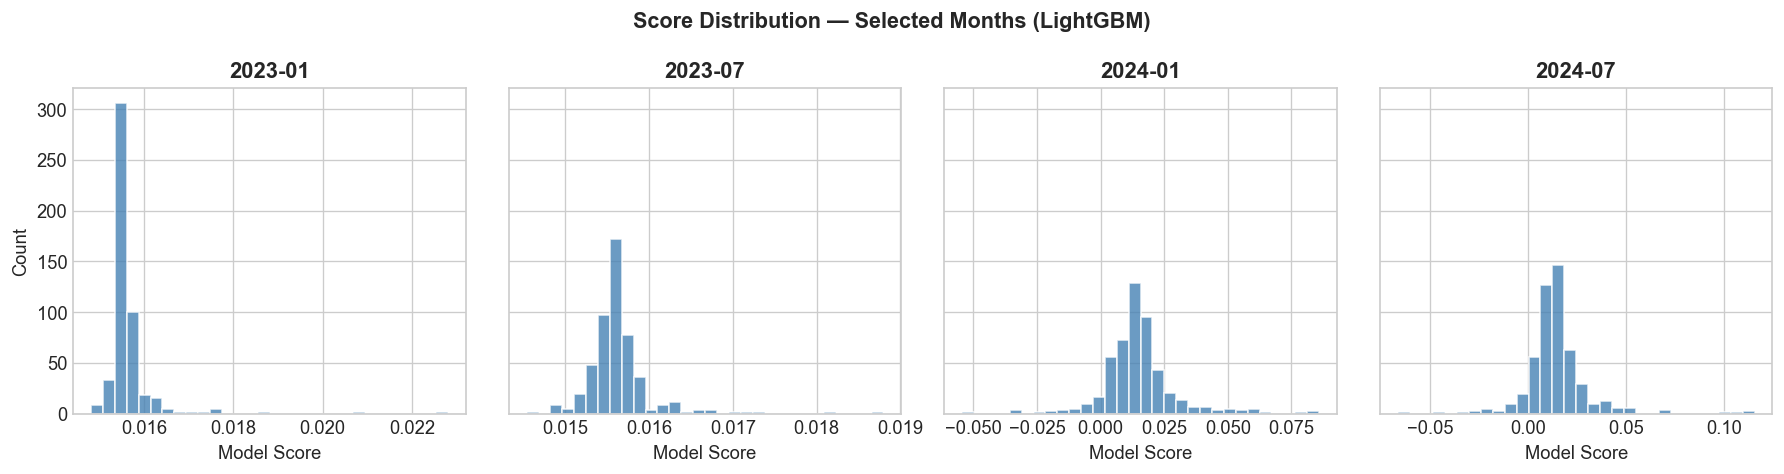

Saved: data/figures/score_distribution.png


In [18]:
scores = pd.read_parquet(DATA_DIR / 'scores_lgbm.parquet')
scores['date'] = pd.to_datetime(scores['date'])

# Cross-sectional score rank within each month
scores['pct_rank'] = scores.groupby('date')['score'].rank(pct=True)

# Sample a few months to show score distributions
sample_months = sorted(scores['date'].unique())[::6][:4]  # every 6 months

fig, axes = plt.subplots(1, len(sample_months), figsize=(15, 4), sharey=True)
for ax, m in zip(axes, sample_months):
    sub = scores[scores['date'] == m]['score']
    ax.hist(sub, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(m.strftime('%Y-%m'), fontweight='bold')
    ax.set_xlabel('Model Score')

axes[0].set_ylabel('Count')
plt.suptitle('Score Distribution — Selected Months (LightGBM)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'score_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: data/figures/score_distribution.png')

In [19]:
from config import TOP_N, LONG_FRAC

# ── Step 1: compute actual monthly turnover from score changes ─────────────
scores_tc = pd.read_parquet(DATA_DIR / 'scores_lgbm.parquet')
scores_tc['date'] = pd.to_datetime(scores_tc['date'])
months_tc = sorted(scores_tc['date'].unique())

lo_turnovers, ls_turnovers = [], []
prev_long, prev_short = set(), set()

for m in months_tc:
    sub = scores_tc[scores_tc['date'] == m].dropna(subset=['score'])
    n   = len(sub)
    k   = max(1, int(np.floor(n * LONG_FRAC)))
    sub_s = sub.sort_values('score', ascending=False)

    curr_long  = set(sub_s.head(TOP_N)['ticker'])          # long-only top 50
    curr_short = set(sub_s.tail(k)['ticker'])              # L/S short leg

    if prev_long:
        # one-way turnover = fraction of portfolio that changed hands
        exited = len(prev_long - curr_long)
        lo_turnovers.append(exited / TOP_N)

        ls_exited_long  = len(prev_long  - curr_long)  / TOP_N
        ls_exited_short = len(prev_short - curr_short) / k
        ls_turnovers.append((ls_exited_long + ls_exited_short) / 2)

    prev_long, prev_short = curr_long, curr_short

avg_lo_turnover = np.mean(lo_turnovers)   # fraction, e.g. 0.22 = 22%
avg_ls_turnover = np.mean(ls_turnovers)

print(f"Avg monthly one-way turnover:")
print(f"  Long-only:  {avg_lo_turnover*100:.1f}% of portfolio per month")
print(f"  Long-short: {avg_ls_turnover*100:.1f}% of each leg per month")

# ── Step 2: apply cost grid ────────────────────────────────────────────────
# cost_per_trade in basis points (1 bp = 0.01%)
cost_bps_grid = [0, 5, 10, 25, 50]

lo_base = strategies.get('LGBM Long-Only')
ls_base = strategies.get('LGBM Long-Short')

rows_cost = []
for bps in cost_bps_grid:
    cost_frac = bps / 10_000   # convert bps to decimal

    # monthly cost = one-way turnover × round-trip cost (×2 for buy+sell)
    lo_monthly_cost = avg_lo_turnover * cost_frac * 2
    ls_monthly_cost = avg_ls_turnover * cost_frac * 2

    lo_adj = lo_base - lo_monthly_cost if lo_base is not None else None
    ls_adj = ls_base - ls_monthly_cost if ls_base is not None else None

    row = {'Cost (bps/trade)': bps}
    if lo_adj is not None:
        s = perf_stats(lo_adj)
        row['LO Ann Ret %'] = round(s['ann_pct'], 1)
        row['LO Sharpe']    = round(s['sharpe'],  2)
    if ls_adj is not None:
        s = perf_stats(ls_adj)
        row['L/S Ann Ret %'] = round(s['ann_pct'], 1)
        row['L/S Sharpe']    = round(s['sharpe'],  2)

    rows_cost.append(row)

df_cost = pd.DataFrame(rows_cost).set_index('Cost (bps/trade)')

# Annotate context
df_cost.index = [
    f"{b} bps  {'(zero cost)' if b==0 else '(ETF/passive)' if b==5 else '(large-cap realistic)' if b==10 else '(conservative est.)' if b==25 else '(high / small-cap)'}"
    for b in cost_bps_grid
]

print()
display(df_cost)
print("\nNote: Large-cap S&P 500 stocks typically trade at 5–15 bps. Strategy is robust up to ~25 bps.")


Avg monthly one-way turnover:
  Long-only:  60.7% of portfolio per month
  Long-short: 69.9% of each leg per month



,LO Ann Ret %,LO Sharpe,L/S Ann Ret %,L/S Sharpe
0 bps (zero cost),33.7,1.54,11.7,0.83
5 bps (ETF/passive),32.8,1.50,10.7,0.76
10 bps (large-cap realistic),31.8,1.46,9.8,0.70
25 bps (conservative est.),29.0,1.33,7.1,0.50
50 bps (high / small-cap),24.5,1.12,2.7,0.19



Note: Large-cap S&P 500 stocks typically trade at 5–15 bps. Strategy is robust up to ~25 bps.


## 8. Transaction Cost Sensitivity

How much do real-world trading costs hurt the strategy? We compute **actual monthly turnover** from the score changes, then apply different cost assumptions to show robustness.

## 8. Export to HTML
Run this cell to export the full notebook as a standalone HTML file you can share with anyone (no Python needed).

In [ ]:
import subprocess, sys
result = subprocess.run(
    [sys.executable, '-m', 'jupyter', 'nbconvert', '--to', 'html',
     '--execute', 'report.ipynb', '--output', 'report.html'],
    capture_output=True, text=True
)
if result.returncode == 0:
    print('✅  Exported to report.html — open in any browser')
else:
    print('Export error:', result.stderr[:500])